# Domain analysis with InterProScan


The goal of the following analysis is to identify conserved motifs of the light chain variable region? If succesful, do these motifs correlate with the immunoglobulin genfamilies and antigen type?

The analysis is supported by InterProScan and ChatGPT.

InterProScan: https://github.com/ebi-pf-team/interproscan/releases  
ChatGPT: https://chatgpt.com/

### Step 1: Installation

1.1 Install InterProScan by downloading latest verion from https://github.com/ebi-pf-team/interproscan/releases  
IMPORTANT: Unzip into a fitting folder, for example:  

cd blasting  
cd domain_analysis  
cd interproscan-5.74-105.0  
tar -xzvf interproscan-5.74-105.0-64-bit.tar.gz  
cd interproscan-5.74-105.0  


1.2 Test if interproscan works; Requirements copy and run in terminal in the folder where interproscan-5.74-105.0 is located:
  
!./interproscan.sh -i test_all_appl.fasta -f tsv  

  
1.3 OPTIONAL: Only once needed, this creates a target directory in the folder of interproscan-5.74-105.0:  
  
!mkdir -p ~/group04-team03/blasting/domain_analysis/interproscan-5.74-105.0/results

#### Step 2: Test if it works with small fasta

In [ ]:
# Setting file directories; Requirment is to have queryOmicron.fasta or any other small fasta to test
# queryOmircon.fasta was create in group04-team03/blasting/domain_analysis/mmseqs2_EVEscape /scripts/TODOblasting_with_ MMseqs2.ipynb 

input_omicron_fasta = "../data/queryOmicron.fasta" # Input for InterProScan anaylsis
output_file = "../inter_pro_scan/results/interproscan.tsv" # Output for tsv files
output_dir = "../inter_pro_scan/results" # General output directory
interproscan_dir = "../interproscan-5.74-105.0" # Location of interproscan, to run without terminal




In [ ]:
# Creating tsv with interproscan: scanning protein sequence against a collection of protein signature databases
import subprocess

cmd = [
    f"{interproscan_dir}/interproscan.sh", # Run interproscan in the specific directory where it was installed
    "-i", input_omicron_fasta, # Input data
    "-f", "tsv", # creating a tsv file
    "-goterms",
    "-iprlookup",
     "--tempdir", "../temp", # Use the group04-team03/blasting/inter_pro_scan/temp folder for temporary files
    "-cpu", "4",
    "-o", output_file # Output file
]

# Run the upper commant 
result = subprocess.run(cmd, capture_output=True, text=True)

# Status
print("Return code:", result.returncode)
print("stdout:\n", result.stdout)
print("stderr:\n", result.stderr)

Return code: 0
stdout:
 30/06/2025 15:18:43:296 Welcome to InterProScan-5.74-105.0
30/06/2025 15:18:43:297 Running InterProScan v5 in STANDALONE mode... on Linux
30/06/2025 15:18:47:960 RunID: TomsBOOK2_20250630_151847856_eloe
30/06/2025 15:18:56:102 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/queryOmicron.fasta
30/06/2025 15:18:56:105 Running the following analyses:
[AntiFam-8.0,CDD-3.21,Coils-2.2.1,FunFam-4.3.0,Gene3D-4.3.0,Hamap-2025_01,MobiDBLite-4.0,NCBIfam-17.0,PANTHER-19.0,Pfam-37.3,PIRSF-3.10,PIRSR-2025_01,PRINTS-42.0,ProSitePatterns-2025_01,ProSiteProfiles-2025_01,SFLD-4,SMART-9.0,SUPERFAMILY-1.75]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-06-30 15:18:57,045 [Thread-6] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

Th

In [ ]:
# First look at result of small fasta scan via pandas
import pandas as pd

# Datei einlesen
df = pd.read_csv(output_file, sep="\t", header=None)

# Add fitting column names
df.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]

df.head()


,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways
0,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,Pfam,PF16451,"Betacoronavirus-like spike glycoprotein S1, N-...",33,337,1.7E-66,T,30-06-2025,IPR032500,"Spike glycoprotein S1, N-terminal domain, beta...",-,-
1,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,Pfam,PF09408,"Betacoronavirus spike glycoprotein S1, recepto...",349,526,1.1E-37,T,30-06-2025,IPR018548,"Spike (S) protein S1 subunit, receptor-binding...",-,-
2,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,ProSiteProfiles,PS51922,Betacoronavirus spike (S) glycoprotein S1 subu...,9,303,49.265945,T,30-06-2025,IPR032500,"Spike glycoprotein S1, N-terminal domain, beta...",-,-
3,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,ProSiteProfiles,PS51921,Betacoronavirus spike (S) glycoprotein S1 subu...,334,527,64.510162,T,30-06-2025,IPR018548,"Spike (S) protein S1 subunit, receptor-binding...",-,-
4,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,Pfam,PF19209,"Coronavirus spike glycoprotein S1, C-terminal",536,592,4.5E-4,T,30-06-2025,IPR043607,"Coronavirus spike glycoprotein S1, C-terminal",-,-


In [ ]:
# Counting domain data and checking output
df["Protein Accession Clean"] = df["Protein Accession"].str.extract(r"^(\w+)")
domain_counts = df.groupby("Protein Accession Clean").size().reset_index(name="Domain Count")

domain_counts.head()


,Protein Accession Clean,Domain Count
0,6VXC_1,13
1,7BNN_1,25
2,7CAB_1,21


In [ ]:
# Save the file if first look and output matched expectation
import os
# Sicherstellen, dass das Verzeichnis existiert
results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)

# Path to the output_path for domain anlysis
output_path = os.path.join(results_dir, "domain_counts_per_protein.tsv")

# Save
domain_counts.to_csv(output_path, sep="\t", index=False)

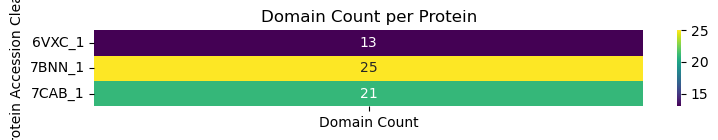

In [ ]:
# Test heatmap with small sample size
import pandas as pd

df = pd.read_csv("../results/domain_counts_per_protein.tsv", sep="\t")
import seaborn as sns
import matplotlib.pyplot as plt

# Protein als Index setzen
df.set_index("Protein Accession Clean", inplace=True)

# Heatmap zeichnen
plt.figure(figsize=(8, max(1, 0.5 * len(df))))
sns.heatmap(df, annot=True, cmap="viridis", cbar=True)
plt.title("Domain Count per Protein")
plt.tight_layout()
plt.show()


### STEP 3 Test subset of 10, 100 and all sequences from lchain_sequences_deduplicated.fasta

In [12]:
# Create subset with 10 sequences
from Bio import SeqIO

input_fasta = "../data/lchain_sequences_deduplicated.fasta"
output_subset = "../data/lchain_subset_10.fasta"

# Number of taken sequences
subset_size = 10

records = list(SeqIO.parse(input_fasta, "fasta"))
subset = records[:subset_size]  # takes the first 10

with open(output_subset, "w") as out_f:
    SeqIO.write(subset, out_f, "fasta")


In [11]:
# Create subset with 100 sequences
from Bio import SeqIO

input_fasta = "../data/lchain_sequences_deduplicated.fasta"
output_subset = "../data/lchain_subset_100.fasta"

# Anzahl der gewünschten Sequenzen
subset_size = 100

records = list(SeqIO.parse(input_fasta, "fasta"))
subset = records[:subset_size]  # takes the first 10

with open(output_subset, "w") as out_f:
    SeqIO.write(subset, out_f, "fasta")


In [10]:
# Input files
input_lchain_fasta ="../data/lchain_subset_10.fasta"
input_lchain_fasta100 ="../data/lchain_subset_100.fasta"
input_lchain_fastatotal = "../data/lchain_sequences_deduplicated.fasta"

# Output files
output_file = "../results/interproscan_lchain_subset_10.tsv"
output_file100 = "../results/interproscan_lchain_subset_100.tsv"
output_filetotal = "../results/interproscan_lchain_total.tsv"

# Directories 
output_dir = "../results"
interproscan_dir = "../interproscan-5.74-105.0"

In [13]:
# SLOW PROCESSING: NOT IN USE
# Creating tsv with interproscan: scanning protein sequence against a collection of protein signature databases
import subprocess

cmd = [
    f"{interproscan_dir}/interproscan.sh", # Run interproscan in the specific directory where it was installed
    "-i", input_lchain_fasta , # Input data
    "-f", "tsv", # creating a tsv file
    "-goterms",
    "-iprlookup",
     "--tempdir", "../temp", # Use the group04-team03/blasting/inter_pro_scan/temp folder for temporary files
    "-cpu", "14",
    "-o", output_file # Output file
]

# Run the upper commant 
result = subprocess.run(cmd, capture_output=True, text=True)

# Status
print("Return code:", result.returncode)
print("stdout:\n", result.stdout)
print("stderr:\n", result.stderr)

KeyboardInterrupt: 

### STEP 4 Faster InterProScan analysis only searching Pfam data bank 

In [ ]:
# FASTER Only Pfam and more cpu cores used
# Standard: InterProScan all 15 data banks 
# For high speed only analyse Pfam data base 
# TODO integrate also Pfam, SMART, ProSiteProfiles -> for domain identification enought

# AND 


import os
import subprocess
import multiprocessing

# Automatisch Anzahl der verfügbaren CPUs ermitteln
cpu_count = max(1, multiprocessing.cpu_count() - 2)

# Debug-Ausgabe (optional)
print(f"Nutze {cpu_count} CPUs für InterProScan")

# InterProScan-Aufruf konfigurieren
cmd = [
    f"{interproscan_dir}/interproscan.sh",
    "-i", input_lchain_fasta,
    "-f", "tsv",
    "-goterms",
    "-iprlookup",
    "--applications", "Pfam",          # only Pfam for speed
    "--tempdir", "../temp",
    "-cpu", str(cpu_count),
    "-o", output_file
]

# Ausführen
result = subprocess.run(cmd, capture_output=True, text=True)

# Status ausgeben
print("Return code:", result.returncode)
print("stdout:\n", result.stdout)
print("stderr:\n", result.stderr)


Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 30/06/2025 15:27:02:457 Welcome to InterProScan-5.74-105.0
30/06/2025 15:27:02:458 Running InterProScan v5 in STANDALONE mode... on Linux
30/06/2025 15:27:08:671 RunID: TomsBOOK2_20250630_152708547_l0rr
30/06/2025 15:27:18:137 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_subset_10.fasta
30/06/2025 15:27:18:137 Running the following analyses:
[Pfam-37.3]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-06-30 15:27:19,183 [Thread-6] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the same, you cannot use this match lookup se

In [ ]:
# First look at result of subset 10 fasta scan via pandas
import pandas as pd

output_file = "../results/interproscan_lchain_subset_10.tsv"

# Datei einlesen
df = pd.read_csv(output_file, sep="\t", header=None)

# Add fitting column names
df.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]
# Save file with new columsn
#df.to_csv(output_file, index=False)

df.head()

,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways
0,7ZOZ_entity3_chainL,7b843020dfe3d0be6728cafced9c965c,214,Pfam,PF07686,Immunoglobulin V-set domain,6,106,6.600000e-15,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-
1,7ZOZ_entity3_chainL,7b843020dfe3d0be6728cafced9c965c,214,Pfam,PF07654,Immunoglobulin C1-set domain,115,201,6.600000e-21,T,30-06-2025,IPR003597,Immunoglobulin C1-set,-,-
2,"4KXZ_entity3_chainI,L,M,P",8d69266d34d52ddd43dddf89dd13fd48,215,Pfam,PF07686,Immunoglobulin V-set domain,6,107,7.600000e-16,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-
3,"4KXZ_entity3_chainI,L,M,P",8d69266d34d52ddd43dddf89dd13fd48,215,Pfam,PF07654,Immunoglobulin C1-set domain,116,202,6.600000e-21,T,30-06-2025,IPR003597,Immunoglobulin C1-set,-,-
4,8IVX_entity3_chainL,ddfd44253613ec1d6358539013c6dd46,215,Pfam,PF07686,Immunoglobulin V-set domain,8,107,2.000000e-13,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-


In [ ]:
# Counting domain data and checking output 
df["Protein Accession Clean"] = df["Protein Accession"].str.extract(r"^(\w+)")
domain_counts = df.groupby("Protein Accession Clean").size().reset_index(name="Domain Count")

domain_counts.head()

,Protein Accession Clean,Domain Count
0,4KXZ_entity3_chainI,2
1,5GGT_entity3_chainL,2
2,6MHR_entity2_chainB,2
3,6PE8_entity2_chainB,2
4,6VMK_entity1_chainC,1


In [ ]:
domain_counts.tail()

,Protein Accession Clean,Domain Count
5,6VMK_entity2_chainA,2
6,6VMK_entity3_chainB,2
7,7ZOZ_entity3_chainL,2
8,8IVW_entity3_chainC,2
9,8IVX_entity3_chainL,2


### STEP 5 Add genfamily information from light_subclass.csv

In [ ]:
import pandas as pd
df_ipr = df
input_file_genfamilies = "../data/light_subclass.csv"
df_genfamilies = pd.read_csv(input_file_genfamilies, sep=",", header=0) # header=0 important for column names

df_ipr.head()

,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways,Protein Accession Clean,pdb,gen_family
0,7ZOZ_entity3_chainL,7b843020dfe3d0be6728cafced9c965c,214,Pfam,PF07686,Immunoglobulin V-set domain,6,106,6.600000e-15,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,7ZOZ_entity3_chainL,7ZOZ_entity3_chainL,NaN
1,7ZOZ_entity3_chainL,7b843020dfe3d0be6728cafced9c965c,214,Pfam,PF07654,Immunoglobulin C1-set domain,115,201,6.600000e-21,T,30-06-2025,IPR003597,Immunoglobulin C1-set,-,-,7ZOZ_entity3_chainL,7ZOZ_entity3_chainL,NaN
2,"4KXZ_entity3_chainI,L,M,P",8d69266d34d52ddd43dddf89dd13fd48,215,Pfam,PF07686,Immunoglobulin V-set domain,6,107,7.600000e-16,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,4KXZ_entity3_chainI,4KXZ_entity3_chainI,NaN
3,"4KXZ_entity3_chainI,L,M,P",8d69266d34d52ddd43dddf89dd13fd48,215,Pfam,PF07654,Immunoglobulin C1-set domain,116,202,6.600000e-21,T,30-06-2025,IPR003597,Immunoglobulin C1-set,-,-,4KXZ_entity3_chainI,4KXZ_entity3_chainI,NaN
4,8IVX_entity3_chainL,ddfd44253613ec1d6358539013c6dd46,215,Pfam,PF07686,Immunoglobulin V-set domain,8,107,2.000000e-13,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,8IVX_entity3_chainL,8IVX_entity3_chainL,NaN


In [ ]:
df_genfamilies.head()

,pdb,antigen_species,light_subclass
0,8wu1,bos taurus | homo sapiens,IGKV1
1,3lqa,hiv-1 | homo sapiens,IGLV1
2,4kxz,homo sapiens,IGKV3
3,6vmk,homo sapiens,IGKV1
4,6vmk,homo sapiens,IGKV1


In [ ]:
# Merge data frame with genfamilie information with data frame with domain information
df_genfamilies["pdb_id"] = df_genfamilies["pdb"].str.extract(r"(\w{4})")[0].str.lower()
df_ipr["pdb_id"] = df_ipr["Protein Accession"].str.extract(r"(\w{4})")[0].str.lower()
merged = pd.merge(df_ipr, df_genfamilies, on="pdb_id", how="left")

import os

os.makedirs("../results", exist_ok=True)
merged.to_csv("../results/merged_ipr_genfamilies.csv", index=False)

merged.head()


,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,...,InterPro Description,GO Terms,Pathways,Protein Accession Clean,pdb_x,gen_family,pdb_id,pdb_y,antigen_species,light_subclass
0,7ZOZ_entity3_chainL,7b843020dfe3d0be6728cafced9c965c,214,Pfam,PF07686,Immunoglobulin V-set domain,6,106,6.600000e-15,T,...,Immunoglobulin V-set domain,-,-,7ZOZ_entity3_chainL,7ZOZ_entity3_chainL,NaN,7zoz,7zoz,homo sapiens,IGKV14
1,7ZOZ_entity3_chainL,7b843020dfe3d0be6728cafced9c965c,214,Pfam,PF07654,Immunoglobulin C1-set domain,115,201,6.600000e-21,T,...,Immunoglobulin C1-set,-,-,7ZOZ_entity3_chainL,7ZOZ_entity3_chainL,NaN,7zoz,7zoz,homo sapiens,IGKV14
2,"4KXZ_entity3_chainI,L,M,P",8d69266d34d52ddd43dddf89dd13fd48,215,Pfam,PF07686,Immunoglobulin V-set domain,6,107,7.600000e-16,T,...,Immunoglobulin V-set domain,-,-,4KXZ_entity3_chainI,4KXZ_entity3_chainI,NaN,4kxz,4kxz,homo sapiens,IGKV3
3,"4KXZ_entity3_chainI,L,M,P",8d69266d34d52ddd43dddf89dd13fd48,215,Pfam,PF07686,Immunoglobulin V-set domain,6,107,7.600000e-16,T,...,Immunoglobulin V-set domain,-,-,4KXZ_entity3_chainI,4KXZ_entity3_chainI,NaN,4kxz,4kxz,homo sapiens,IGKV3
4,"4KXZ_entity3_chainI,L,M,P",8d69266d34d52ddd43dddf89dd13fd48,215,Pfam,PF07686,Immunoglobulin V-set domain,6,107,7.600000e-16,T,...,Immunoglobulin V-set domain,-,-,4KXZ_entity3_chainI,4KXZ_entity3_chainI,NaN,4kxz,4kxz,homo sapiens,IGKV3


In [ ]:
### Visulization with heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Tabelle: wie oft kommt jede Domain-Beschreibung pro light_subclass vor?
heatmap_data = (
    merged.groupby(["light_subclass", "Signature Description"])
    .size()
    .unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=0.5, linecolor="gray")
plt.title("Domain-Vorkommen pro Light Subclass")
plt.xlabel("Signature Description")
plt.ylabel("Light Subclass")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

### STEP 6 Function for faster analysis

In [8]:
# Function for FAST InterProScan

import os
import subprocess
import multiprocessing

def run_interproscan(interproscan_dir, input_fasta_path, output_path, temp_dir="../temp", applications="Pfam", extra_args=None):
    """
    Führt InterProScan mit konfigurierter Anwendung aus.

    Args:
        interproscan_dir (str): Pfad zum InterProScan-Installationsverzeichnis.
        input_fasta_path (str): Pfad zur Eingabe-FASTA-Datei.
        output_path (str): Zielpfad für die TSV-Ausgabe.
        temp_dir (str): Verzeichnis für temporäre Dateien (Default: "../temp").
        applications (str): Datenbanken für Analyse, z.B. "Pfam" oder "Pfam,SMART,ProSiteProfiles".
        extra_args (list): Zusätzliche Argumente als Liste (optional).

    Returns:
        result (subprocess.CompletedProcess): Ergebnisobjekt von subprocess.run
    """
    cpu_count = max(1, multiprocessing.cpu_count() - 2)
    print(f"Nutze {cpu_count} CPUs für InterProScan")

    cmd = [
        os.path.join(interproscan_dir, "interproscan.sh"),
        "-i", input_fasta_path,
        "-f", "tsv",
        "-goterms",
        "-iprlookup",
        "--applications", applications,
        "--tempdir", temp_dir,
        "-cpu", str(cpu_count),
        "-o", output_path
    ]

    if extra_args:
        cmd.extend(extra_args)

    result = subprocess.run(cmd, capture_output=True, text=True)

    print("Return code:", result.returncode)
    print("stdout:\n", result.stdout)
    print("stderr:\n", result.stderr)

    return result

In [14]:
# RUNNING 100 -> 100 sequences creating a interproscan file
run_interproscan(
    interproscan_dir= "../interproscan-5.74-105.0",
    input_fasta_path= "../data/lchain_subset_100.fasta",
    output_path = output_file100,
    applications="Pfam" 
)

Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 01/07/2025 13:49:38:664 Welcome to InterProScan-5.74-105.0
01/07/2025 13:49:38:664 Running InterProScan v5 in STANDALONE mode... on Linux
01/07/2025 13:49:43:943 RunID: TomsBOOK2_20250701_134943807_3dyi
01/07/2025 13:49:52:325 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_subset_100.fasta
01/07/2025 13:49:52:326 Running the following analyses:
[Pfam-37.3]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-07-01 13:49:53,385 [Thread-6] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the same, you cannot use this match lookup s

CompletedProcess(args=['../interproscan-5.74-105.0/interproscan.sh', '-i', '../data/lchain_subset_100.fasta', '-f', 'tsv', '-goterms', '-iprlookup', '--applications', 'Pfam', '--tempdir', '../temp', '-cpu', '14', '-o', '../results/interproscan_lchain_subset_100.tsv'], returncode=0, stdout='01/07/2025 13:49:38:664 Welcome to InterProScan-5.74-105.0\n01/07/2025 13:49:38:664 Running InterProScan v5 in STANDALONE mode... on Linux\n01/07/2025 13:49:43:943 RunID: TomsBOOK2_20250701_134943807_3dyi\n01/07/2025 13:49:52:325 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_subset_100.fasta\n01/07/2025 13:49:52:326 Running the following analyses:\n[Pfam-37.3]\nAvailable matches will be retrieved from the pre-calculated match lookup service.\n\nMatches for any sequences that are not represented in the lookup service will be calculated locally.\n2025-07-01 13:49:53,385 [Thread-6] [uk.ac.ebi.interpro.scan.business.sequence.Ber

In [ ]:
import pandas as pd

input_file_ipr100 = "../results/interproscan_lchain_subset_100.tsv"
df_ipr100 = pd.read_csv(input_file_ipr100, sep="\t", header=1)
df_ipr100.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]

input_file_genfamilies = "../data/light_subclass.csv"
df_genfamilies100 = pd.read_csv(input_file_genfamilies, sep=",", header=0) # header=0 important for column names


In [ ]:
# RUNNING total -> all sequences
run_interproscan(
    interproscan_dir= "../interproscan-5.74-105.0",
    input_fasta_path = input_lchain_fastatotal,
    output_path= output_filetotal,
    applications="Pfam" 
)

Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 30/06/2025 16:14:23:126 Welcome to InterProScan-5.74-105.0
30/06/2025 16:14:23:126 Running InterProScan v5 in STANDALONE mode... on Linux
30/06/2025 16:14:29:497 RunID: TomsBOOK2_20250630_161429358_4f5x
30/06/2025 16:14:38:828 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_sequences_deduplicated.fasta
30/06/2025 16:14:38:829 Running the following analyses:
[Pfam-37.3]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-06-30 16:14:40,473 [Thread-12] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the same, you cannot use this m

CompletedProcess(args=['../interproscan-5.74-105.0/interproscan.sh', '-i', '../data/lchain_sequences_deduplicated.fasta', '-f', 'tsv', '-goterms', '-iprlookup', '--applications', 'Pfam', '--tempdir', '../temp', '-cpu', '14', '-o', '../results/interproscan_lchain_total.tsv'], returncode=0, stdout='30/06/2025 16:14:23:126 Welcome to InterProScan-5.74-105.0\n30/06/2025 16:14:23:126 Running InterProScan v5 in STANDALONE mode... on Linux\n30/06/2025 16:14:29:497 RunID: TomsBOOK2_20250630_161429358_4f5x\n30/06/2025 16:14:38:828 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_sequences_deduplicated.fasta\n30/06/2025 16:14:38:829 Running the following analyses:\n[Pfam-37.3]\nAvailable matches will be retrieved from the pre-calculated match lookup service.\n\nMatches for any sequences that are not represented in the lookup service will be calculated locally.\n2025-06-30 16:14:40,473 [Thread-12] [uk.ac.ebi.interpro.scan.b

In [ ]:
# MERGING total
import pandas as pd
input_file_total = "../results/interproscan_lchain_total.tsv"
df_ipr_total = pd.read_csv(input_file_total, sep="\t", header=0) 

df_ipr_total.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]
input_file_genfamilies = "../data/light_subclass.csv"
df_genfamilies = pd.read_csv(input_file_genfamilies, sep=",", header=0) # header=0 important for column names


df_genfamilies["pdb_id"] = df_genfamilies["pdb"].str.extract(r"(\w{4})")[0].str.lower()
df_ipr_total["pdb_id"] = df_ipr_total["Protein Accession"].str.extract(r"(\w{4})")[0].str.lower()
merged_total = pd.merge(df_ipr_total, df_genfamilies, on="pdb_id", how="left")

import os

os.makedirs("../results", exist_ok=True)
merged_total.to_csv("../results/merged_total_ipr_genfamilies.csv", index=False)

merged_total.head()

,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways,pdb_id,pdb,antigen_species,light_subclass
0,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,Pfam,PF07686,Immunoglobulin V-set domain,5,108,4.100000e-15,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,6mi2,6mi2,homo sapiens,IGLV3
1,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,Pfam,PF07686,Immunoglobulin V-set domain,5,108,4.100000e-15,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,6mi2,6mi2,homo sapiens,IGLV3
2,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1
3,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1
4,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1


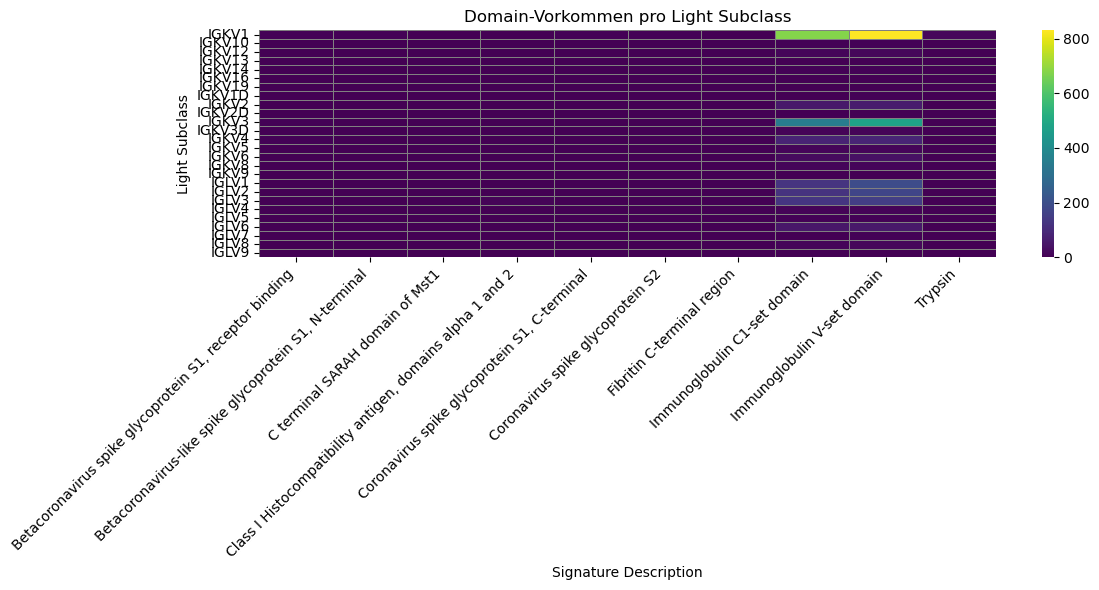

In [ ]:
### Creating heatmap for total
import seaborn as sns
import matplotlib.pyplot as plt

# Tabelle: wie oft kommt jede Domain-Beschreibung pro light_subclass vor?
heatmap_data = (
    merged_total.groupby(["light_subclass", "Signature Description"])
    .size()
    .unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=0.5, linecolor="gray")
plt.title("Domain-Vorkommen pro Light Subclass")
plt.xlabel("Signature Description")
plt.ylabel("Light Subclass")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### STEP 7 Running process with Pfam,SMART,ProSiteProfiles and all  

In [55]:
# RUNNING total fasta (-> all sequences) with Pfam, SMART and ProSiteProfiles
output_filetotal_Pfam_SMART_ProSiteProfiles = "../results/interproscan_lchain_total_Pfam_SMART_ProSiteProfiles.tsv"

run_interproscan(
    interproscan_dir= "../interproscan-5.74-105.0",
    input_fasta_path = input_lchain_fastatotal,
    output_path= output_filetotal_Pfam_SMART_ProSiteProfiles,
    applications="Pfam,SMART,ProSiteProfiles" 
)

Nutze 14 CPUs für InterProScan


KeyboardInterrupt: 

In [64]:
# MERGING total with all applications
import pandas as pd
input_file_total_Pfam_SMART_ProSiteProfiles  = "../results/interproscan_lchain_total_Pfam_SMART_ProSiteProfiles.tsv"
df_ipr_total_Pfam_SMART_ProSiteProfiles = pd.read_csv(input_file_total_Pfam_SMART_ProSiteProfiles , sep="\t", header=0) 

df_ipr_total_Pfam_SMART_ProSiteProfiles .columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]
input_file_genfamilies = "../data/light_subclass.csv"
df_genfamilies = pd.read_csv(input_file_genfamilies, sep=",", header=0) # header=0 important for column names


df_genfamilies["pdb_id"] = df_genfamilies["pdb"].str.extract(r"(\w{4})")[0].str.lower()
df_ipr_total_Pfam_SMART_ProSiteProfiles ["pdb_id"] = df_ipr_total_Pfam_SMART_ProSiteProfiles ["Protein Accession"].str.extract(r"(\w{4})")[0].str.lower()
merged_total_Pfam_SMART_ProSiteProfiles  = pd.merge(df_ipr_total_Pfam_SMART_ProSiteProfiles , df_genfamilies, on="pdb_id", how="left")

import os

os.makedirs("../results", exist_ok=True)
merged_total_Pfam_SMART_ProSiteProfiles .to_csv("../results/merged_total_ipr_genfamilies.csv", index=False)

merged_total_Pfam_SMART_ProSiteProfiles.head()

,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways,pdb_id,pdb,antigen_species,light_subclass
0,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00409,IG_3c,7,108,6.700000e-13,T,30-06-2025,IPR003599,Immunoglobulin domain subtype,-,-,6mi2,6mi2,homo sapiens,IGLV3
1,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00409,IG_3c,7,108,6.700000e-13,T,30-06-2025,IPR003599,Immunoglobulin domain subtype,-,-,6mi2,6mi2,homo sapiens,IGLV3
2,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00409,IG_3c,121,209,4.800000e+01,T,30-06-2025,IPR003599,Immunoglobulin domain subtype,-,-,6mi2,6mi2,homo sapiens,IGLV3
3,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00409,IG_3c,121,209,4.800000e+01,T,30-06-2025,IPR003599,Immunoglobulin domain subtype,-,-,6mi2,6mi2,homo sapiens,IGLV3
4,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00407,igc1_4,131,205,5.700000e-30,T,30-06-2025,IPR003597,Immunoglobulin C1-set,-,-,6mi2,6mi2,homo sapiens,IGLV3


In [56]:
# 
import seaborn as sns
import matplotlib.pyplot as plt
import re

def plot_domain_heatmap600x0(
    df,
     value_col="Signature Description",
    class_col="light_subclass",
    min_total_count=600,
    cell_size=1.0,
    dpi=300,
    save_path=None
):
    """
    Plot heatmap with square, enlarged cells and high resolution, with numerically sorted subclasses.

    Parameters:
    - df: DataFrame
    - value_col: Domain column
    - class_col: Subclass column
    - min_total_count: Minimal domain count across all subclasses
    - cell_size: Cell size in inches
    - dpi: Plot resolution
    - save_path: Optional path to save image
    """
    # Aggregieren
    heatmap_data = (
        df.groupby([class_col, value_col])
        .size()
        .unstack(fill_value=0)
    )

    # Filter
    domain_totals = heatmap_data.sum(axis=0)
    filtered = heatmap_data.loc[:, domain_totals[domain_totals >= min_total_count].index]

    # Umbenennen "Immunoglobulin" zu "Ig"
    filtered.columns = filtered.columns.str.replace("Immunoglobulin", "Ig", regex=False)

    # Sortierung nach Nummer extrahiert aus light_subclass
    def subclass_sort_key(name):
        match = re.search(r"(\d+)", name)
        return (name[:4], int(match.group(1)) if match else 999)

    filtered = filtered.sort_index(key=lambda x: x.map(subclass_sort_key))

    # Größen berechnen
    n_rows, n_cols = filtered.shape
    fig_width = max(8, n_cols * cell_size)
    fig_height = max(6, n_rows * cell_size)

    # Plot
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    sns.heatmap(
        filtered,
        cmap="Blues",
        linewidths=0.2,
        linecolor="gray",
        square=True,
        cbar_kws={"shrink": 0.5},
        ax=ax
    )

    ax.set_title("domains in light subclass", fontsize=16)
    ax.set_xlabel("Signature Description", fontsize=12)
    ax.set_ylabel("light subclass", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()


In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import re

def plot_domain_heatmap600x600(
    df,
    value_col="Signature Description",
    class_col="light_subclass",
    min_total_count=600,
    cell_size=1.0,
    dpi=300,
    save_path=None
):
    """
    Plot heatmap of domain frequencies per light subclass with filters for:
    - minimum total domain count across subclasses
    - minimum total domain count per subclass
    """
    # Gruppierung
    heatmap_data = (
        df.groupby([class_col, value_col])
        .size()
        .unstack(fill_value=0)
    )

    # Spalten (Domains) filtern
    domain_totals = heatmap_data.sum(axis=0).astype(int)
    domain_mask = domain_totals > min_total_count
    heatmap_data = heatmap_data.loc[:, domain_mask]

    # Zeilen (Subklassen) filtern
    subclass_totals = heatmap_data.sum(axis=1).astype(int)
    subclass_mask = subclass_totals > min_total_count
    heatmap_data = heatmap_data.loc[subclass_mask, :]

    # Umbenennung: Immunoglobulin → Ig
    heatmap_data.columns = heatmap_data.columns.str.replace("Immunoglobulin", "Ig", regex=False)

    # Subklassen sortieren numerisch
    def subclass_sort_key(name):
        match = re.search(r"(\d+)", name)
        return (name[:4], int(match.group(1)) if match else 999)

    heatmap_data = heatmap_data.sort_index(key=lambda x: x.map(subclass_sort_key))

    # Größe berechnen
    n_rows, n_cols = heatmap_data.shape
    fig_width = max(8, n_cols * cell_size)
    fig_height = max(6, n_rows * cell_size)

    # Plot erstellen
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.2,
        linecolor="gray",
        square=True,
        cbar_kws={"shrink": 0.5},
        ax=ax
    )

    ax.set_title("Domains in Light Subclass", fontsize=16)
    ax.set_xlabel("Signature Description [>600 counts]", fontsize=12)
    ax.set_ylabel("Light Subclass [>600 counts]", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()


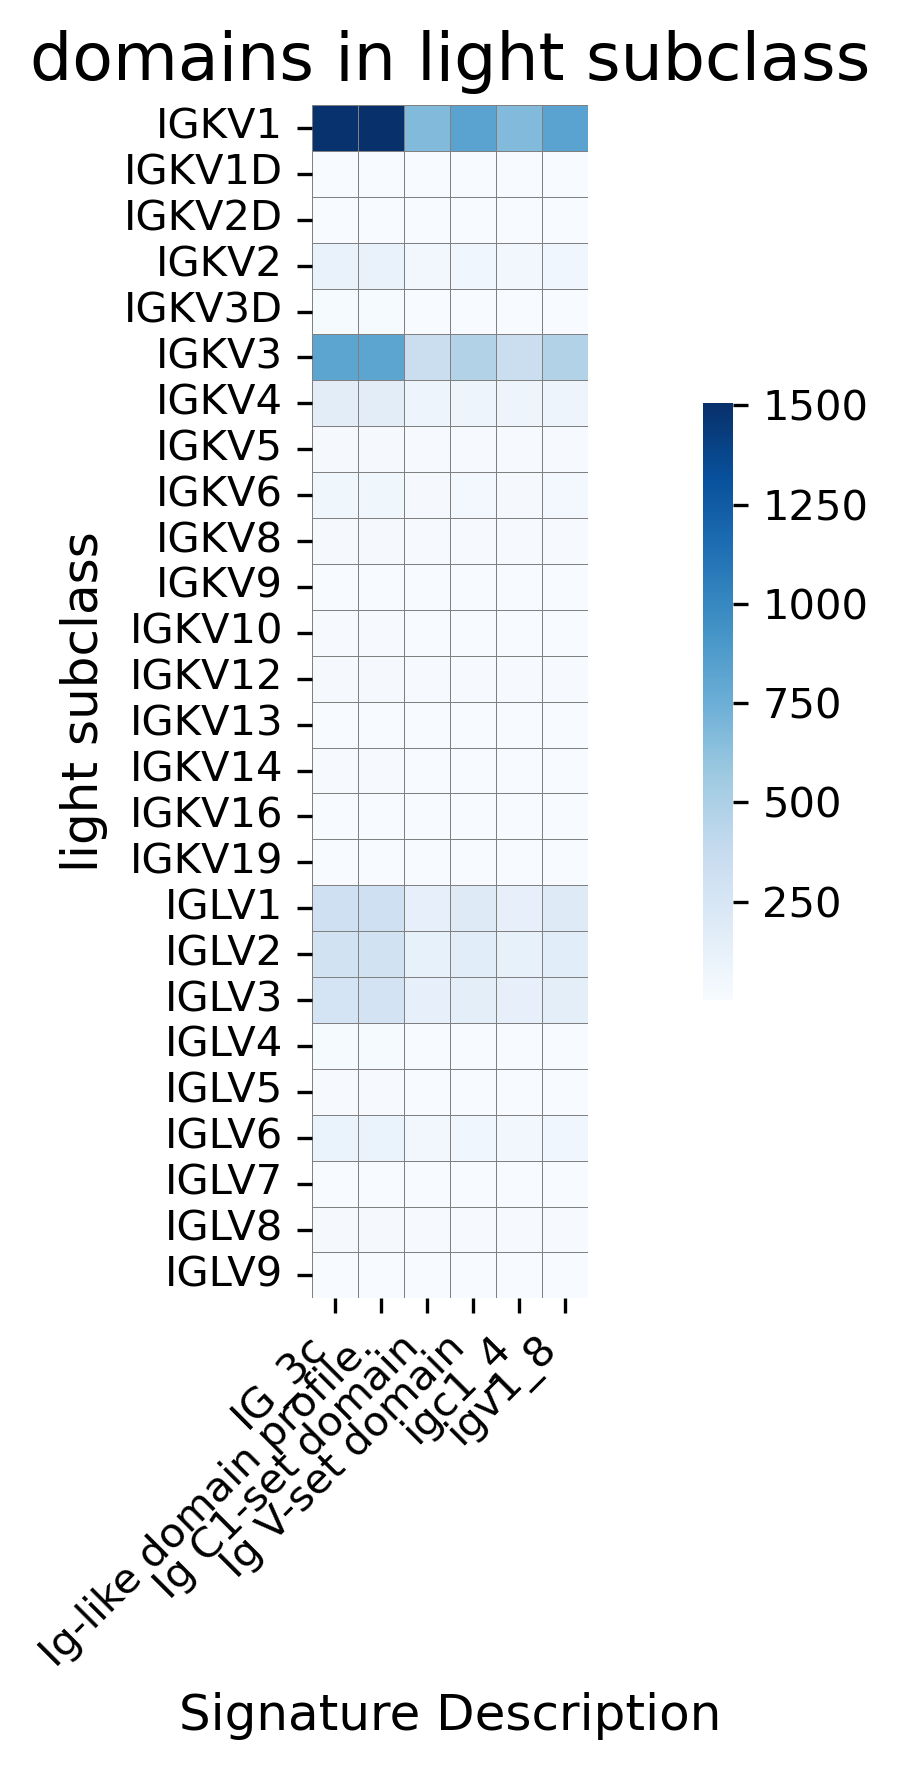

In [58]:
plot_domain_heatmap600x0(
    merged_total_Pfam_SMART_ProSiteProfiles,
    min_total_count=600,
    cell_size=0.1,
    dpi=300,
    save_path="../results/heatmap_sorted.png"
)


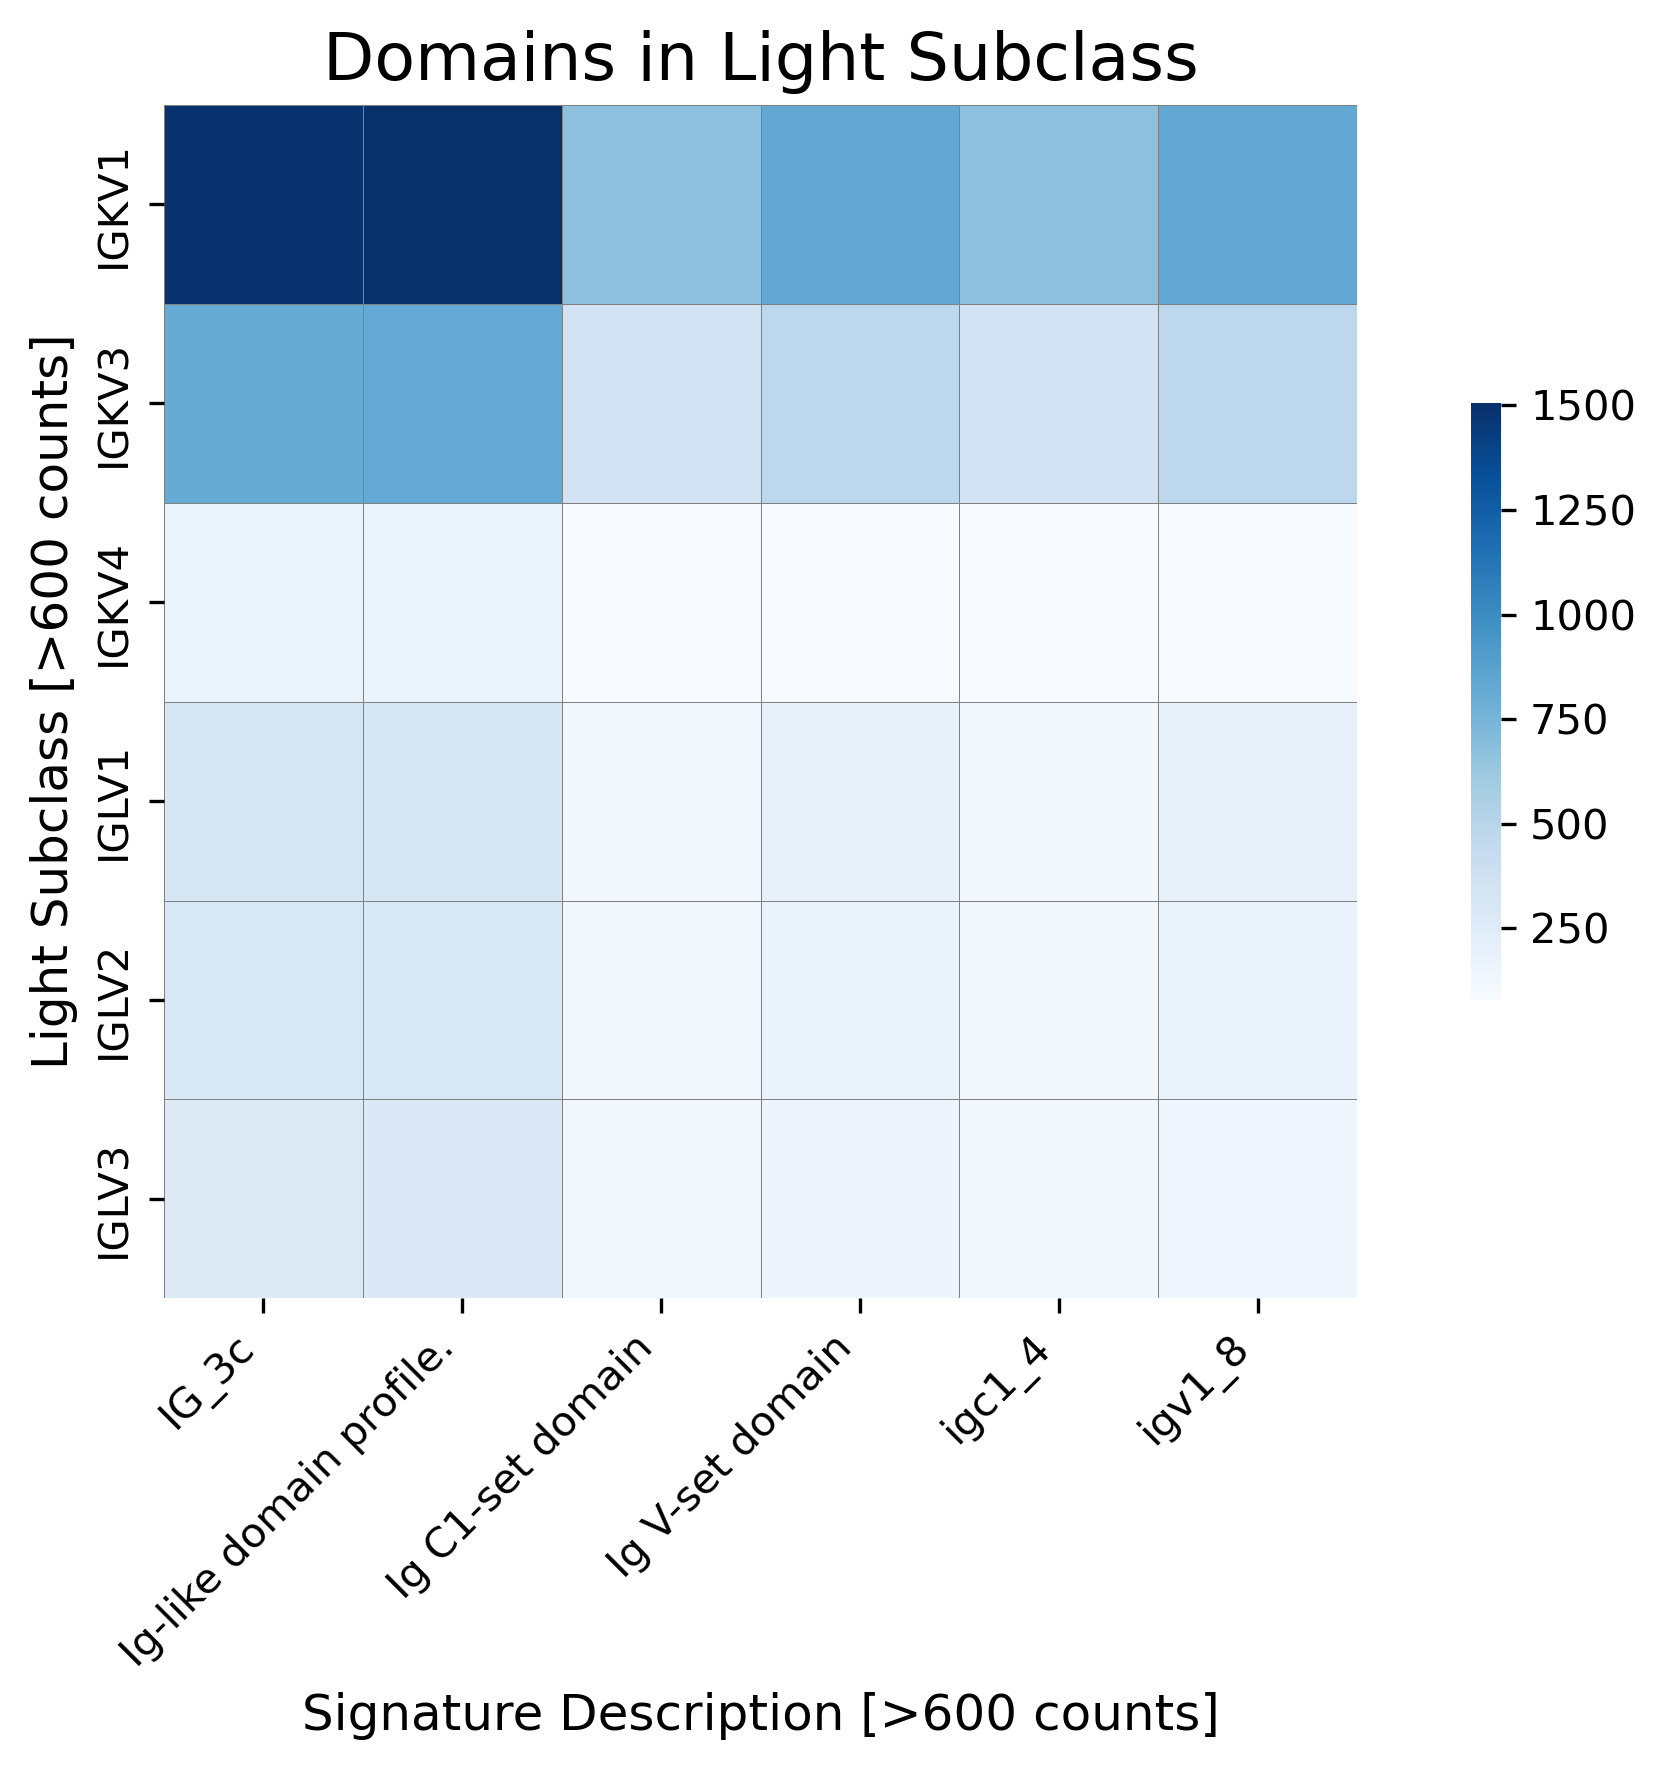

In [63]:
plot_domain_heatmap600x600(
    merged_total_Pfam_SMART_ProSiteProfiles,
    min_total_count=600,
    cell_size=0.1,
    dpi=300,
    save_path="../results/heatmap_sorted.png"
)

In [ ]:
# RUNNING total with all applications-> all sequences and all data bases
output_filetotal_all_applications = "../results/interproscan_lchain_total_all_applications.tsv"

run_interproscan(
    interproscan_dir= "../interproscan-5.74-105.0",
    input_fasta_path = input_lchain_fastatotal,
    output_path= output_filetotal_all_applications,
)

Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 01/07/2025 13:51:46:076 Welcome to InterProScan-5.74-105.0
01/07/2025 13:51:46:078 Running InterProScan v5 in STANDALONE mode... on Linux
01/07/2025 13:51:53:369 RunID: TomsBOOK2_20250701_135153201_doat
01/07/2025 13:52:08:260 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_sequences_deduplicated.fasta
01/07/2025 13:52:08:262 Running the following analyses:
[Pfam-37.3]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-07-01 13:52:10,274 [Thread-14] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the same, you cannot use this m

CompletedProcess(args=['../interproscan-5.74-105.0/interproscan.sh', '-i', '../data/lchain_sequences_deduplicated.fasta', '-f', 'tsv', '-goterms', '-iprlookup', '--applications', 'Pfam', '--tempdir', '../temp', '-cpu', '14', '-o', '../results/interproscan_lchain_total_all_applications.tsv'], returncode=0, stdout='01/07/2025 13:51:46:076 Welcome to InterProScan-5.74-105.0\n01/07/2025 13:51:46:078 Running InterProScan v5 in STANDALONE mode... on Linux\n01/07/2025 13:51:53:369 RunID: TomsBOOK2_20250701_135153201_doat\n01/07/2025 13:52:08:260 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_sequences_deduplicated.fasta\n01/07/2025 13:52:08:262 Running the following analyses:\n[Pfam-37.3]\nAvailable matches will be retrieved from the pre-calculated match lookup service.\n\nMatches for any sequences that are not represented in the lookup service will be calculated locally.\n2025-07-01 13:52:10,274 [Thread-14] [uk.ac.eb

In [65]:
# MERGING total
import pandas as pd
input_file_total_all_applications = "../results/interproscan_lchain_total_all_applications.tsv"
df_ipr_total_all_applications = pd.read_csv(input_file_total_all_applications, sep="\t", header=0) 

df_ipr_total_all_applications.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]
input_file_genfamilies = "../data/light_subclass.csv"
df_genfamilies = pd.read_csv(input_file_genfamilies, sep=",", header=0) # header=0 important for column names


df_genfamilies["pdb_id"] = df_genfamilies["pdb"].str.extract(r"(\w{4})")[0].str.lower()
df_ipr_total_all_applications["pdb_id"] = df_ipr_total_all_applications["Protein Accession"].str.extract(r"(\w{4})")[0].str.lower()
merged_total_all_applications = pd.merge(df_ipr_total_all_applications, df_genfamilies, on="pdb_id", how="left")

import os

os.makedirs("../results", exist_ok=True)
merged_total_all_applications.to_csv("../results/merged_total_ipr_genfamilies.csv", index=False)

merged_total_all_applications.head()

,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways,pdb_id,pdb,antigen_species,light_subclass
0,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,Pfam,PF07686,Immunoglobulin V-set domain,5,108,4.100000e-15,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,6mi2,6mi2,homo sapiens,IGLV3
1,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,Pfam,PF07686,Immunoglobulin V-set domain,5,108,4.100000e-15,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,6mi2,6mi2,homo sapiens,IGLV3
2,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1
3,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1
4,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1


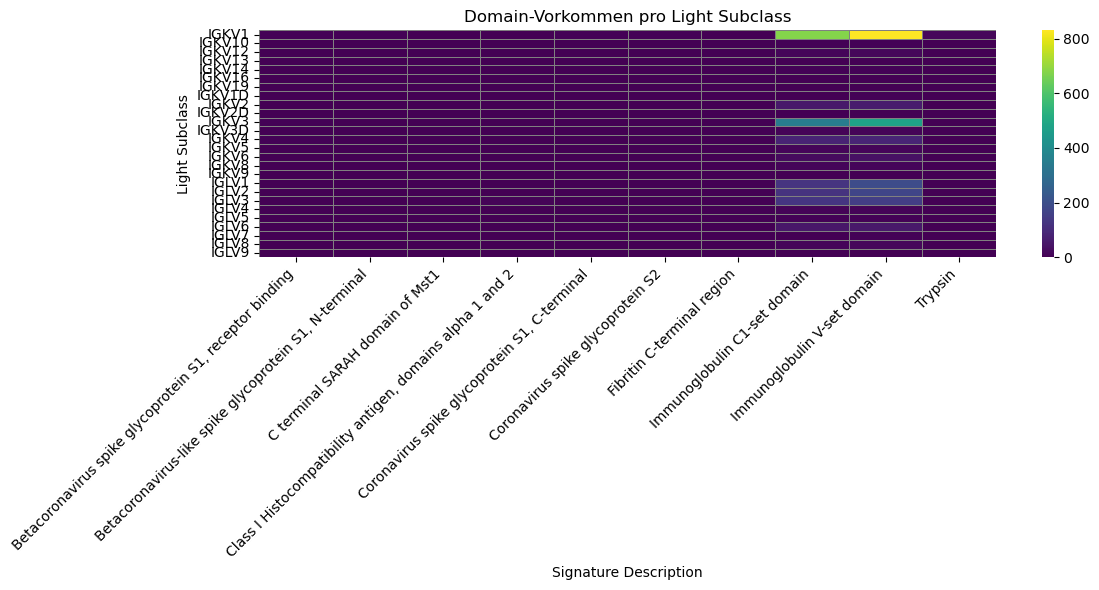

In [24]:
### Creating heatmap for total
import seaborn as sns
import matplotlib.pyplot as plt

# Tabelle: wie oft kommt jede Domain-Beschreibung pro light_subclass vor?
heatmap_data = (
    merged_total_all_applications.groupby(["light_subclass", "Signature Description"])
    .size()
    .unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=0.5, linecolor="gray")
plt.title("Domain-Vorkommen pro Light Subclass")
plt.xlabel("Signature Description")
plt.ylabel("Light Subclass")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### STEP 8 Test with antigen species

In [76]:
merged_total_Pfam_SMART_ProSiteProfiles["antigen_species"] = merged_total_Pfam_SMART_ProSiteProfiles["antigen_species"].str.replace(r"\s*\|\s*", ", ").str.lower()
merged_total_Pfam_SMART_ProSiteProfiles["antigen_species"] = merged_total_Pfam_SMART_ProSiteProfiles["antigen_species"].str.replace(r"(homo sapiens, )*homo sapiens", "homo sapiens", regex=True)


/tmp/ipykernel_1277/764884563.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


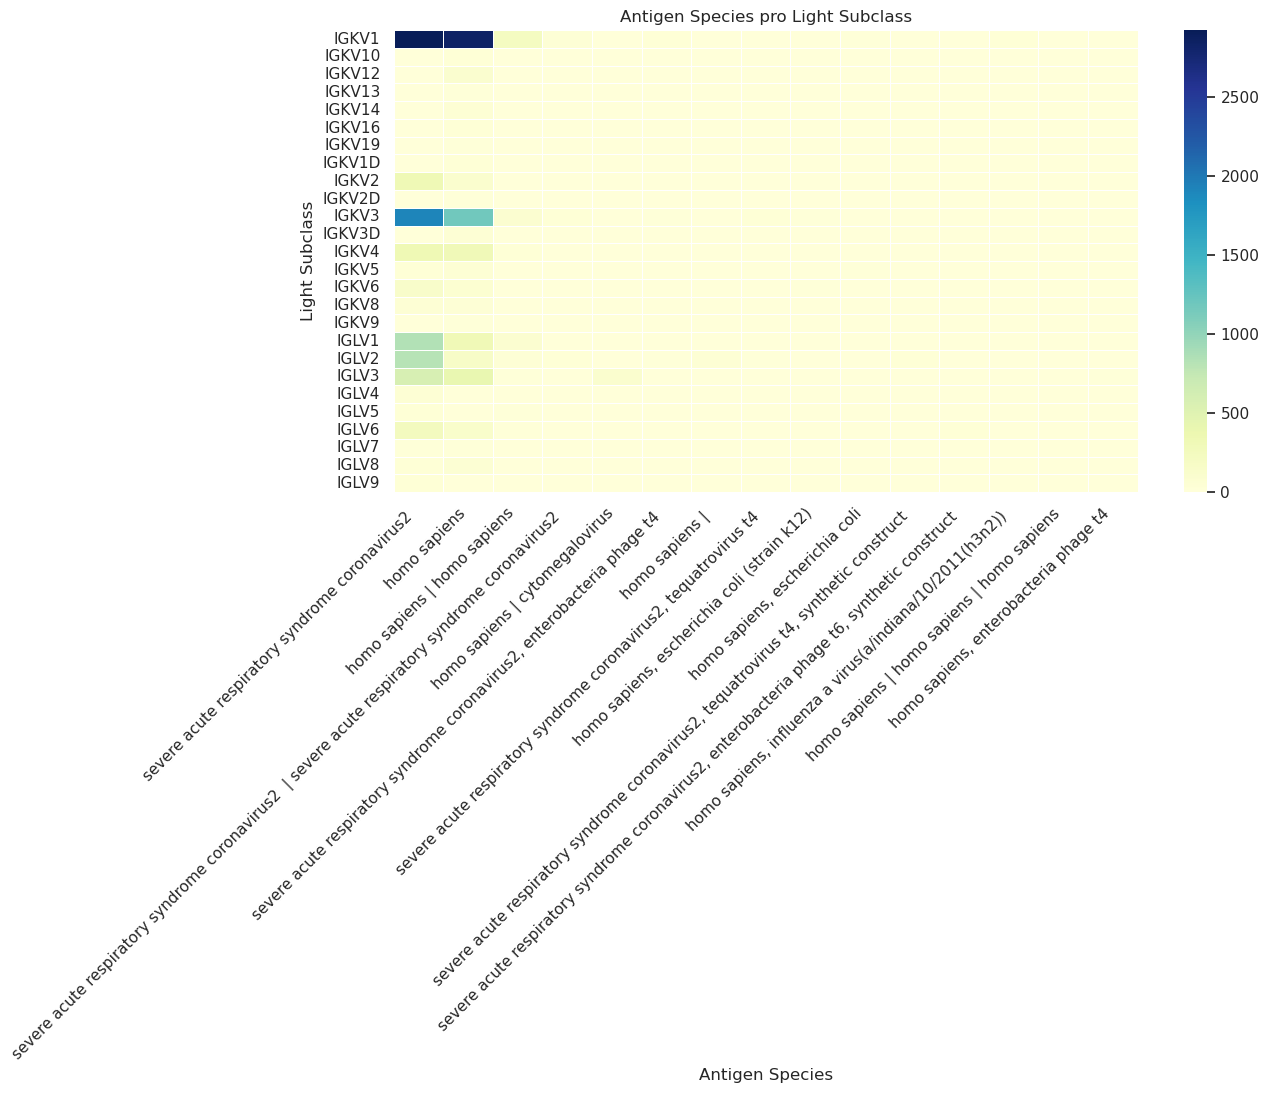

In [ ]:
species_heatmap = (
    merged_total_Pfam_SMART_ProSiteProfiles.groupby(["light_subclass", "antigen_species"])
    .size()
    .unstack(fill_value=0)
)

# Optional nur die häufigsten Spezies anzeigen
top_species = species_heatmap.sum().sort_values(ascending=False).head(15).index
filtered = species_heatmap[top_species]

plt.figure(figsize=(12, 6))
sns.heatmap(filtered, cmap="YlGnBu", linewidths=0.5)
plt.title("Antigen Species pro Light Subclass")
plt.xlabel("Antigen Species")
plt.ylabel("Light Subclass")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


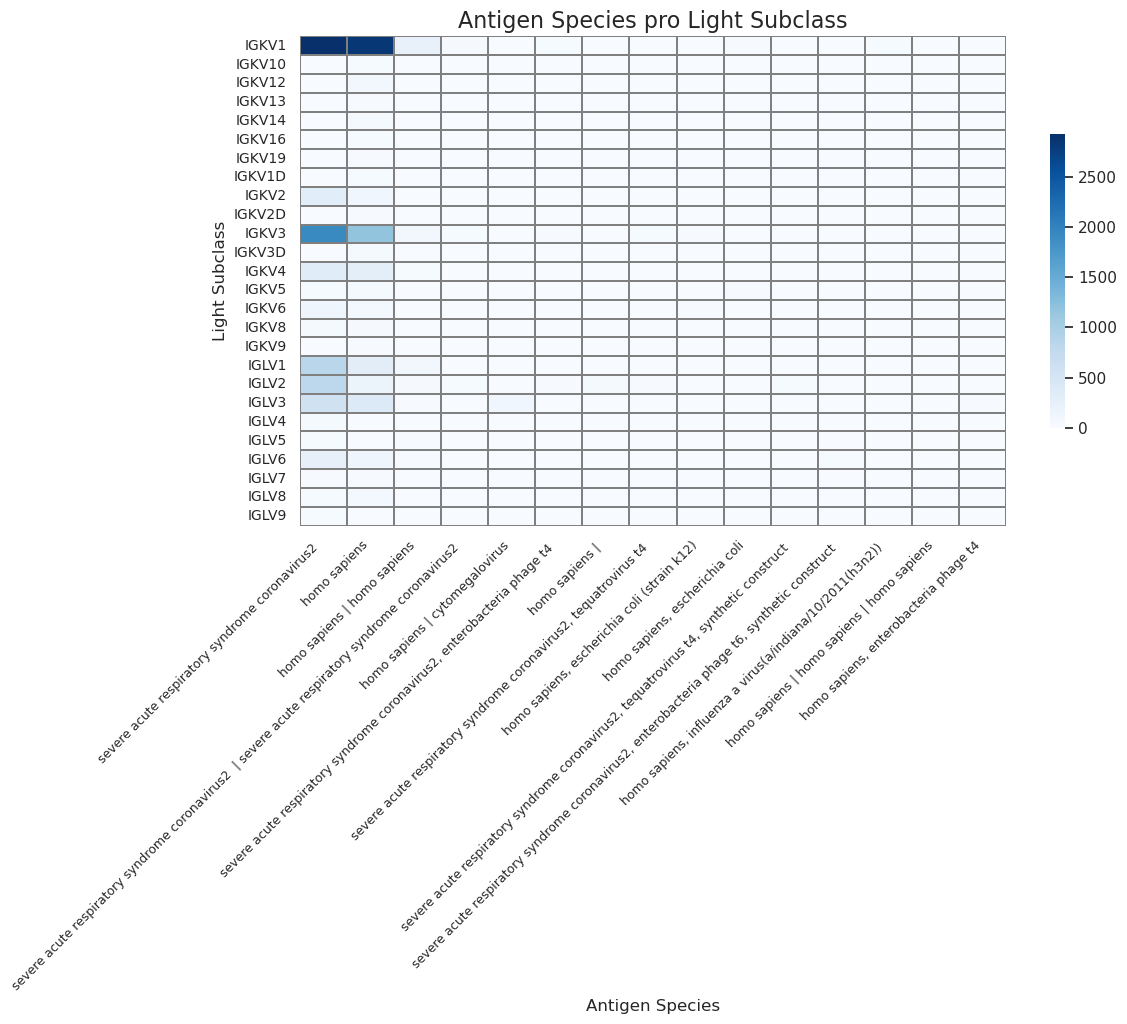

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Erstelle Heatmap mit klarerem Layout
plt.figure(figsize=(max(12, len(filtered.columns) * 0.6), max(6, len(filtered.index) * 0.4)))
ax = sns.heatmap(
    filtered,
    cmap="Blues",
    linewidths=0.3,
    linecolor="gray",
    square=False,
    cbar_kws={"shrink": 0.6},
)

# Achsentitel und Beschriftung
ax.set_title("Antigen Species pro Light Subclass", fontsize=16)
ax.set_xlabel("Antigen Species", fontsize=12)
ax.set_ylabel("Light Subclass", fontsize=12)

# Achsenticks anpassen
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

plt.tight_layout()
plt.show()


### STEP 9 Focused analysis - End of experimenting

Motifs we are searching for?  
Conserved regions in the Complementarity Determining Region (CDR), conserved domains or specific amino acids patterns which are often in the varibale genfamilies and correlated with antigen type.

#### Creating df

Row: All different antibodies
Columns: Antibody_ID, V-Gene Family, Light Chain Type, CDR1, CDR2, CDR3, InterPro Domains, Antigen Type, PDB_ID 

Instead of ANARCI, we try a heuristic approach with defined position windows of the CDRs

In [121]:
from pathlib import Path
import pandas as pd

# Input and output files
fasta_file = "../data/lchain_sequences_deduplicated.fasta"
output_file = "../results/light_chain_cdrs_heuristic.csv"

output_dir = "../results"
interproscan_dir = "../interproscan-5.74-105.0"

In [113]:
# Import fasta, differentiate header and add ID + Seq
def parse_fasta(file_path):
    records = []
    with open(file_path, "r") as f:
        entry = {}
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if entry:
                    records.append(entry)
                entry = {"ID": line[1:], "Seq": ""}
            else:
                entry["Seq"] += line.upper()
        if entry:
            records.append(entry)
    return records

# Identify CDR position window
def extract_cdrs(records):
    for r in records:
        seq = r["Seq"]
        r["CDR1"] = seq[26:36] if len(seq) >= 36 else ""
        r["CDR2"] = seq[49:58] if len(seq) >= 58 else ""
        r["CDR3"] = seq[88:100] if len(seq) >= 100 else ""
    return records

# Seperate header into PDB, entity and chain
def explode_fasta_headers(records):
    exploded = []
    for r in records:
        header = r["ID"]
        seq = r["Seq"]
        cdr1 = r.get("CDR1", "")
        cdr2 = r.get("CDR2", "")
        cdr3 = r.get("CDR3", "")

        try:
            pdb_id = header[:4].upper()
            parts = header.split("_")
            entity = [p for p in parts if p.startswith("entity")]
            chains = [p for p in parts if p.startswith("chain")]

            entity_id = entity[0].replace("entity", "") if entity else ""
            chain_ids = chains[0].replace("chain", "").split(",") if chains else []

            for c in chain_ids:
                exploded.append({
                    "PDB_ID": pdb_id,
                    "Entity_ID": entity_id,
                    "Chain_ID": c,
                    "FASTA_ID": header,
                    "Seq": seq,
                    "CDR1": cdr1,
                    "CDR2": cdr2,
                    "CDR3": cdr3
                })
        except Exception as e:
            print(f"Error header parsing {header} — {e}")
    return pd.DataFrame(exploded)

# Run 
def main():
    if not Path(fasta_file).exists():
        print(f"FASTA not found {fasta_file}")
        return

    Path(output_dir).mkdir(parents=True, exist_ok=True)

    print("Read FASTA")
    records = parse_fasta(fasta_file)

    print("CDR identified")
    records = extract_cdrs(records)

    print("Split HEADER")
    df = explode_fasta_headers(records)

    print(f"Save RESULT{output_file}")
    df.to_csv(output_file, index=False)
    print("DONE")

if __name__ == "__main__":
    main()


Read FASTA
CDR identified
Split HEADER
Save RESULT../results/light_chain_cdrs_heuristic.csv
DONE


In [ ]:
# InterproScan
import pandas as pd
from pathlib import Path

# === Eingabe: CSV mit Sequenzen ===
input_csv = "../results/light_chain_cdrs_heuristic.csv"
output_fasta = "../results/light_chains_for_ipr.fasta"

df = pd.read_csv(input_csv)

# Erzeuge FASTA-Datei (eine Zeile pro Sequence)
with open(output_fasta, "w") as f:
    for _, row in df.iterrows():
        header = f">{row['PDB_ID']}_{row['Chain_ID']}"
        seq = row["Seq"]
        f.write(f"{header}\n{seq}\n")

print(f"Save FASTA: {output_fasta}")


Save fasta: ../results/light_chains_for_ipr.fasta


In [126]:
# Run interproscan FAST STEP 7
run_interproscan(
    interproscan_dir="../interproscan-5.74-105.0",
    input_fasta_path="../results/light_chains_for_ipr.fasta",
    output_path="../results/lightchains.tsv",
    temp_dir="../temp",
    applications="Pfam,SMART,ProSiteProfiles"
)


Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 01/07/2025 20:52:24:243 Welcome to InterProScan-5.74-105.0
01/07/2025 20:52:24:243 Running InterProScan v5 in STANDALONE mode... on Linux
01/07/2025 20:52:29:537 RunID: TomsBOOK2_20250701_205229411_1r2m
01/07/2025 20:52:39:786 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../results/light_chains_for_ipr.fasta
01/07/2025 20:52:39:794 Running the following analyses:
[Pfam-37.3,ProSiteProfiles-2025_01,SMART-9.0]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-07-01 20:52:43,504 [Thread-15] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the

CompletedProcess(args=['../interproscan-5.74-105.0/interproscan.sh', '-i', '../results/light_chains_for_ipr.fasta', '-f', 'tsv', '-goterms', '-iprlookup', '--applications', 'Pfam,SMART,ProSiteProfiles', '--tempdir', '../temp', '-cpu', '14', '-o', '../results/lightchains.tsv'], returncode=0, stdout='01/07/2025 20:52:24:243 Welcome to InterProScan-5.74-105.0\n01/07/2025 20:52:24:243 Running InterProScan v5 in STANDALONE mode... on Linux\n01/07/2025 20:52:29:537 RunID: TomsBOOK2_20250701_205229411_1r2m\n01/07/2025 20:52:39:786 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../results/light_chains_for_ipr.fasta\n01/07/2025 20:52:39:794 Running the following analyses:\n[Pfam-37.3,ProSiteProfiles-2025_01,SMART-9.0]\nAvailable matches will be retrieved from the pre-calculated match lookup service.\n\nMatches for any sequences that are not represented in the lookup service will be calculated locally.\n2025-07-01 20:52:43,504 [Thread-

In [128]:
# Connecting interproscan information with main df (light_chain_cdrs_heuristic.csv)
# Input data files
master_path = "../results/light_chain_cdrs_heuristic.csv"
interpro_path = "../results/lightchains.tsv"

# Using master df
master_df = pd.read_csv(master_path)

# Interproscan results
interpro_df = pd.read_csv(interpro_path, sep="\t", header=None)

# Name columns of interpro_df
interpro_df.columns = [
    "protein_accession", "sequence_md5", "seq_length", "analysis", "signature_accession",
    "signature_description", "start", "end", "score", "status", "date", "interpro_accession",
    "interpro_description", "GO_terms", "pathways"
]

# Identify PDB_ID und Chain_ID aus protein_accession
interpro_df["PDB_ID"] = interpro_df["protein_accession"].str[:4].str.upper()
interpro_df["Chain_ID"] = interpro_df["protein_accession"].str[5:].str.upper()

# MERGE
merged_df = pd.merge(master_df, interpro_df, on=["PDB_ID", "Chain_ID"], how="left")

# Save result
merged_df.to_csv("../results/light_chains_with_domains.csv", index=False)

print("MERGED Succesfully. light_chains_with_domains.csv")


MERGED Succesfully. light_chains_with_domains.csv


In [ ]:
# Cleaned the data frame light subclasses 
# The result light_subclass_filtered_exact only contains:
# "homo sapiens"
# "severe acute respiratory syndrome coronavirus2"

import pandas as pd

# Eingabe-/Ausgabepfade
input_file = "../data/light_subclass.csv"
output_file = "../results/light_subclass_filtered_exact.csv"

# Einlesen
df = pd.read_csv(input_file)

# Kleinbuchstaben, Whitespace säubern
df["antigen_species"] = df["antigen_species"].str.lower().str.strip()

# Nur exakt diese beiden Einträge erlauben
allowed = [
    "homo sapiens",
    "severe acute respiratory syndrome coronavirus2"
]

# Nur exakte Übereinstimmungen (kein contains!)
df_filtered = df[df["antigen_species"].isin(allowed)].copy()

# Optional: Duplikate pro PDB entfernen
df_filtered = df_filtered.drop_duplicates(subset="pdb")

# Speichern
df_filtered.to_csv(output_file, index=False)
print(f"✅ Nur reine human- oder SARS-CoV-2-Einträge gespeichert unter: {output_file}")




✅ Nur reine human- oder SARS-CoV-2-Einträge gespeichert unter: ../results/light_subclass_filtered_exact.csv


In [ ]:
# Also identifies the 1D in IGKV1D

import pandas as pd

# === Dateipfade ===
domains_file = "../results/light_chains_with_domains.csv"
antigen_file = "../results/light_subclass_filtered_exact.csv"
output_file = "../results/light_chains_with_domains_and_antigens.csv"

# === 1. Dateien einlesen ===
domains_df = pd.read_csv(domains_file)
antigen_df = pd.read_csv(antigen_file)

# === 2. PDB-ID normalisieren ===
domains_df["PDB_ID"] = domains_df["PDB_ID"].str.upper()
antigen_df["pdb"] = antigen_df["pdb"].str.upper()

# === 3. Nur eindeutige PDBs für Antigen-Tabelle
antigen_df_unique = antigen_df.drop_duplicates(subset="pdb")

# === 4. Merge durchführen (inner join → nur passende behalten)
merged_df = pd.merge(
    domains_df,
    antigen_df_unique[["pdb", "antigen_species", "light_subclass"]],
    left_on="PDB_ID",
    right_on="pdb",
    how="inner"
)

# === 5. V-Gene-Familie aus light_subclass extrahieren (inkl. Sonderzeichen wie D, - etc.)
def extract_gene_family(subclass):
    if isinstance(subclass, str):
        subclass = subclass.strip().upper()
        if subclass.startswith("IGKV") or subclass.startswith("IGLV"):
            family_type = subclass[:4]         # z.B. IGKV
            family_rest = subclass[4:]         # z.B. 1D oder 3-21
            return pd.Series([family_type, family_rest])
    return pd.Series(["", ""])

merged_df[["V_Gene", "V_Family"]] = merged_df["light_subclass"].apply(extract_gene_family)

# Aufräumen
merged_df.drop(columns=["pdb"], inplace=True)

# === 6. Speichern
merged_df.to_csv(output_file, index=False)
print(f"✅ Merge + vollständige V-Gene-Familie abgeschlossen. Datei gespeichert unter: {output_file}")


✅ Merge + vollständige V-Gene-Familie abgeschlossen. Datei gespeichert unter: ../results/light_chains_with_domains_and_antigens.csv


##### Analysis of the created MASTER data frame

FRIST -> Count variable genfamily per antigen species


In [149]:
import pandas as pd

# === Eingabedatei ===
input_file = "../results/light_chains_with_domains_and_antigens.csv"

# === Daten laden ===
df = pd.read_csv(input_file)

# === V_Family × antigen_species zählen ===
v_family_counts = df.groupby(["V_Family", "antigen_species"]).size().unstack(fill_value=0)

# === Ergebnis anzeigen ===
print("\n📊 Häufigkeit von V_Family pro Antigen-Spezies:")
print(v_family_counts)

# === Optional: Als CSV speichern ===
v_family_counts.to_csv("../results/v_family_antigen_counts.csv")
print("\n✅ Ergebnis gespeichert unter: ../results/v_family_antigen_counts.csv")



📊 Häufigkeit von V_Family pro Antigen-Spezies:
antigen_species  homo sapiens  severe acute respiratory syndrome coronavirus2
V_Family                                                                     
1                        3056                                            2876
10                         40                                               0
12                         72                                               0
13                         15                                               0
14                         48                                               0
16                         24                                               0
19                         16                                               0
1D                         28                                               0
2                         276                                             910
2D                         16                                               0
3               

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# === Dateipfade ===
input_file = "../results/light_chains_with_domains_and_antigens.csv"
output_file = "../results/v_gene_family_distribution_within_family_exact_p.png"

# === Daten einlesen
df = pd.read_csv(input_file)

# === Familiennummern vereinfachen
def simplify_family(fam):
    try:
        fam_int = int(fam)
        return str(fam_int) if fam_int < 10 else "10–14"
    except:
        return fam

df["V_Family_Simple"] = df["V_Family"].apply(simplify_family)
df["V_Gene_Family"] = df["V_Gene"].str.upper() + df["V_Family_Simple"]

# === Kreuztabelle: V_Gene_Family × antigen_species
table = df.groupby(["V_Gene_Family", "antigen_species"]).size().unstack(fill_value=0)

# === Chi²-Test
chi2, p, dof, expected = chi2_contingency(table)
p_str = f"p = {p:.2e}"  # z. B. p = 1.21e-154

# === Prozentuale Verteilung innerhalb jeder V-Family
percent_table = table.div(table.sum(axis=1), axis=0) * 100

# === Farbenblindenfreundliche Palette
colors = plt.get_cmap("Paired").colors[:percent_table.shape[1]]

# === Plot
plt.figure(figsize=(12, 6))
percent_table.plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="black",
    linewidth=0.5,
    ax=plt.gca()
)

plt.title(
    f"Antigen Species Distribution within Each V-Gene Family\nChi² test {p_str}",
    fontsize=13
)
plt.xlabel("V-Gene Family (simplified)")
plt.ylabel("Proportion within each V-Gene Family (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Antigen Species", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

# === Speichern
plt.savefig(output_file, dpi=300)
plt.close()

print(f"✅ Plot gespeichert unter: {output_file}")
print(f"ℹ️  Chi² test {p_str}")


✅ Plot gespeichert unter: ../results/v_gene_family_distribution_within_family_exact_p.png
ℹ️  Chi² test p = 5.54e-241


Nullhypothese wird verworfen -> p < 0.05  
H_0: variable genfamilies are independent from the antigen species (homo sapiens vs SARS2)

In [ ]:
Effekt etc. stärken




Clusterung nach Familie: IGHV1, IGHV2, IGKV3 etc.

Zuordnung zu Antigentyp
Nutzt die PDB-Daten: z. B. viral vs. bakteriell vs. zellulär vs. Toxin etc.

Antigentypen kategorisieren, evtl. mit Hilfe von PDB Annotationen oder durch manuelles Curation / Mapping

c) Motifs extrahieren
Fokussiert euch auf CDR1–3 – ausgerichtet nach Kabat oder IMGT-Nummerierung

Motif-Suche mit Tools wie:

MEME Suite (für de novo Motif Discovery)

GLAM2 (gapped motifs)

HMMER (wenn ihr Profile/Alignments habt)

Sekundär: InterProScan-Ergebnisse vergleichen

Statistische Analyse
Korrelation von Motif-Vorkommen (oder InterPro-Domains) mit Antigentypen

Chi²-Test oder Fisher’s exact test zur Signifikanzanalyse

Clustering / Heatmaps der Motif-Vorkommen über V-Familien vs. Antigentypen

Fragen beantworten ->
Gibt es bestimmte Motive in CDRs, die wiederholt bei Antikörpern auftreten, die gegen z. B. virale Antigene gerichtet sind?

Sind bestimmte V-Gene-Familien stark auf bestimmte Antigentypen spezialisiert?

Gibt es InterPro-Domains, die mit funktioneller Spezifität verknüpft sind?

#### Motif analysis of CDR1, CDR2 and CDR3

In [ ]:
# Searching CDR1,CDR2 and especially CDR3 for domain motifs
# Frist create faster for each antigen species
import pandas as pd
import os

# === Eingabe- und Ausgabe-Pfade ===
input_file = "../results/light_chains_with_domains_and_antigens.csv"
output_dir = "../results"

# === Sicherstellen, dass Output-Verzeichnis existiert ===
os.makedirs(output_dir, exist_ok=True)

# === Daten einlesen ===
df = pd.read_csv(input_file)

# === Exportiere jede CDR separat nach Antigen-Spezies ===
cdr_types = ["CDR1", "CDR2", "CDR3"]

for cdr in cdr_types:
    for species in df["antigen_species"].dropna().unique():
        # Dateinamen aufräumen
        species_name = species.replace(" ", "_").replace("/", "_").lower()
        filename = f"{cdr}_{species_name}.fasta"
        full_path = os.path.join(output_dir, filename)

        # Filter und Export
        subset = df[df["antigen_species"] == species]

        with open(full_path, "w") as f:
            for i, seq in enumerate(subset[cdr].dropna()):
                f.write(f">{cdr}_{species_name}_{i+1}\n{seq}\n")

        print(f"✅ Exportiert: {full_path}")